# EDA ActiConnect mock-database V10

Voordat ik mijn dashboard ga bouwen wil ik eerst zelf exploren in de data en trends ontdekken.
Wat zit erin, klopt het allemaal, en zie ik dingen terug die ik in mijn bedrijfsadvies heb opgeschreven.

Bewegen-vermindert-stress, lunch- en na-werk-piek, het idee dat hybride werken sociale interactie kost?

Ik werk per onderwerp door. Per stuk noteer ik wat ik zie en of het overeenkomt met wat ik verwachtte.

In [2]:
# Standaard set imports.
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 80)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

In [3]:
# Ik laad alle CSV's eerst als string (dtype=str).
OUTPUT = Path('output')

def laad_tabellen(map_):
    tabellen = {}
    for p in sorted(map_.glob('*.csv')):
        tabellen[p.stem] = pd.read_csv(p, dtype=str,
                                       na_values=['', 'NULL', 'null', 'None'])
    return tabellen

tabellen = laad_tabellen(OUTPUT)
print(f'{len(tabellen)} tabellen geladen')

26 tabellen geladen


In [ ]:
# Kleine helper die kolommen omzet naar getal/datum. Heuristisch op naam, niet super netjes maar voor verkennende analyse prima.

GETAL_HINTS = ('_id','count','score','rate','avg','_min','max','kg','cm',
               'stappen','minuten','duur','calorie','distance','hartslag',
               'budget','punten','amount','rang','target','capaciteit',
               'gewicht','lengte','pct','aantal','energie','stress','1tot',
               'beoordeling','verbondenheid','jaren','slaap','uren','bpm',
               'factor','steps')
DATUM_HINTS = ('datum','tijd','timestamp','aangemaakt_op','geboortedatum',
               'aanmeld','laatste_login','indienst','behaald_op','toegetreden',
               'startdatum','einddatum','verlenging','verbonden_sinds',
               'ingediend_op','verstuurd_op','snapshot_datum','week_startdatum',
               'check_in_tijd','check_out_tijd','toegevoegd_op')

def cast(df):
    out = df.copy()
    for c in out.columns:
        lc = c.lower()
        if any(h in lc for h in GETAL_HINTS):
            out[c] = pd.to_numeric(out[c], errors='coerce')
        elif any(h in lc for h in DATUM_HINTS):
            out[c] = pd.to_datetime(out[c], errors='coerce')
    return out

# De tabellen die ik veel ga gebruiken cast ik vast:
med  = cast(tabellen['medewerkers'])
act  = cast(tabellen['activiteiten'])
dn   = cast(tabellen['deelnames'])
aw   = cast(tabellen['aanwezigheid'])
gez  = cast(tabellen['gezondheidsmetingen'])
org  = cast(tabellen['organisaties'])
fb   = cast(tabellen['feedback'])
rl   = cast(tabellen['ranglijst_snapshots'])
afd  = cast(tabellen['afdelingen'])
sp   = cast(tabellen['sportcategorieen'])
prof = cast(tabellen['medewerker_profielen'])

Casting klaar


## 1. Hoe ziet de database er eigenlijk uit?

Eerst even een gevoel krijgen voor de omvang. Hoeveel rijen per tabel, en welke tabellen zijn vooral 'groot'?

In [5]:
overzicht = (
    pd.DataFrame([
        {
            'tabel': naam,
            'rijen': df.shape[0],
            'kolommen': df.shape[1],
            'lege_cellen': int(df.isna().sum().sum()),
        }
        for naam, df in tabellen.items()
    ])
    .sort_values('rijen', ascending=False)
    .reset_index(drop=True)
)
print(f"Totaal: {overzicht['rijen'].sum():,} rijen over {len(overzicht)} tabellen")
overzicht

Totaal: 428,912 rijen over 26 tabellen


,tabel,rijen,kolommen,lege_cellen
0,notificaties,122191,7,466
1,platform_gebeurtenissen,81147,7,0
2,deelnames,58630,7,3169
3,aanwezigheid,34308,10,6809
4,dashboard_dagelijks,31875,11,5059
5,gezondheidsmetingen,27987,10,2814
6,feedback,18801,10,12381
7,activiteit_tags,10699,3,0
8,connecties,9196,5,0
9,behaalde_prestaties,7805,5,0


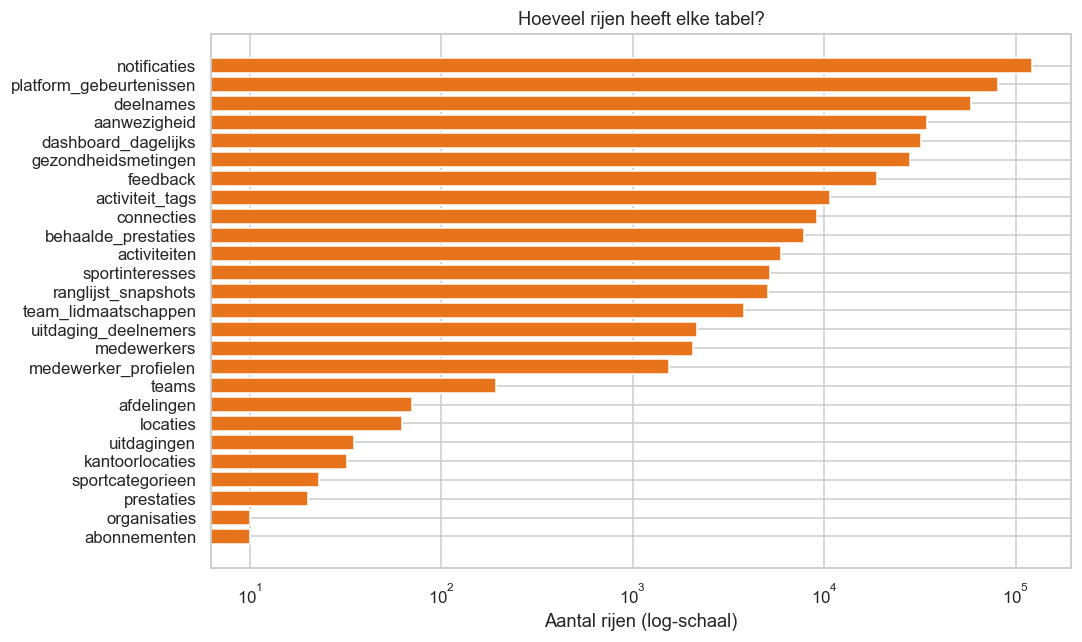

In [7]:
# Bar chart van rij-aantallen, gesorteerd.
fig, ax = plt.subplots(figsize=(10, 6))
data = overzicht.sort_values('rijen', ascending=True)
ax.barh(data['tabel'], data['rijen'], color='#E8731D')
ax.set_xscale('log')   # log-schaal, anders zie ik de kleine tabellen niet eens
ax.set_xlabel('Aantal rijen (log-schaal)')
ax.set_title('Hoeveel rijen heeft elke tabel?')
plt.tight_layout()
plt.show()

Wat me opvalt:

- `notificaties` is verreweg de grootste.
- `platform_gebeurtenissen` is ook gigantisch 
- `deelnames` (~58k) is consistent met ~5k activiteiten × ~10 deelnemers per stuk.

Volgende stap: datakwaliteit checken.

## 2. Datakwaliteit

Bewust ~3–5% data-fouten ingebouwd. Ik wil zien of ik ze allemaal terugvind voor ik conclusies trek.

In [6]:
# Per tabel: percentage missing per kolom. Ik wil alleen kolommen zien die
# echt iets missen.
rijen = []
for naam, df in tabellen.items():
    miss = df.isna().mean() * 100
    for col, pct in miss.items():
        if pct > 0:
            rijen.append({'tabel': naam, 'kolom': col, 'pct_missing': round(pct, 2)})

missend = pd.DataFrame(rijen).sort_values('pct_missing', ascending=False).reset_index(drop=True)
missend

,tabel,kolom,pct_missing
0,activiteiten,team_id,82.58
1,feedback,opmerking,65.85
2,medewerker_profielen,bio,62.14
3,activiteiten,omschrijving,39.10
4,activiteiten,locatie_id,15.64
5,aanwezigheid,hartslag_gem,10.11
6,aanwezigheid,hartslag_piek,9.74
7,dashboard_dagelijks,gem_hartslag,9.47
8,dashboard_dagelijks,doel_voortgang_pct,6.40
9,deelnames,bijgewoond,5.41


In [8]:

zware = prof[prof['gewicht_kg'] > 200]
print(f'Medewerkers met gewicht > 200 kg: {len(zware)} (allemaal duidelijke outliers)')
if len(zware):
    print(zware[['medewerker_id','lengte_cm','gewicht_kg']].head().to_string(index=False))

nul_stappen = (gez['gem_stappen_per_dag'] == 0).sum()
print(f'\nWeek-records met 0 stappen: {nul_stappen}  ({nul_stappen/len(gez)*100:.2f}% van de metingen)')

Medewerkers met gewicht > 200 kg: 6 (allemaal duidelijke outliers)
 medewerker_id  lengte_cm  gewicht_kg
           221      181.8       210.8
           394      179.1       214.7
           882      166.1       227.0
          1467      172.7       235.0
          1979      165.6       233.9

Week-records met 0 stappen: 127  (0.45% van de metingen)


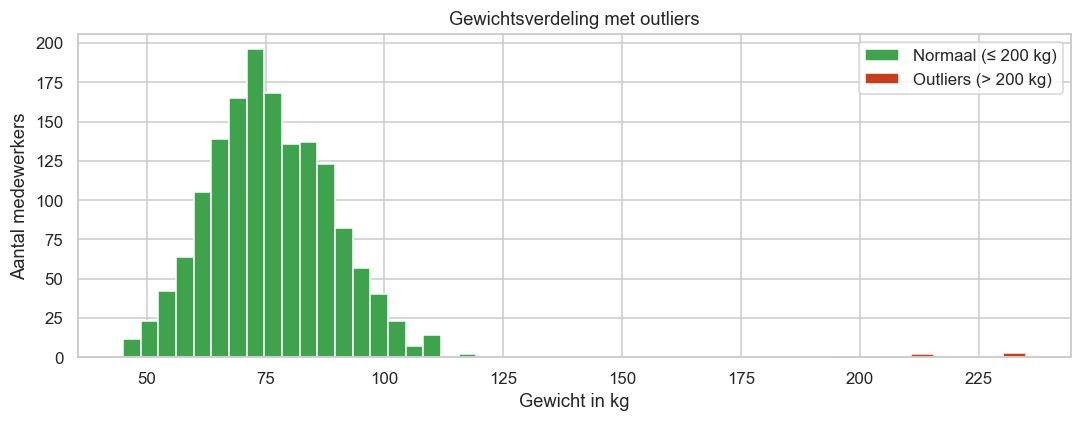

In [9]:
# Gewicht-verdeling, outliers laten zien in een andere kleur zodat ik ze
# meteen herken.
fig, ax = plt.subplots(figsize=(10, 4))
w = prof['gewicht_kg'].dropna()
ax.hist(w[w <= 200], bins=40, color='#3FA34D', label='Normaal (≤ 200 kg)')
ax.hist(w[w > 200], bins=5, color='#C73E1D', label='Outliers (> 200 kg)')
ax.set_xlabel('Gewicht in kg')
ax.set_ylabel('Aantal medewerkers')
ax.set_title('Gewichtsverdeling met outliers')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Wie zit er in deze dataset?

Voor mijn dashboard wil ik weten met wat voor populatie ik werk: leeftijd, geslacht en werkwijze. Dat laatste is relevant want in mijn advies (H2.1) staat dat hybride werkers minder informele contacten hebben.

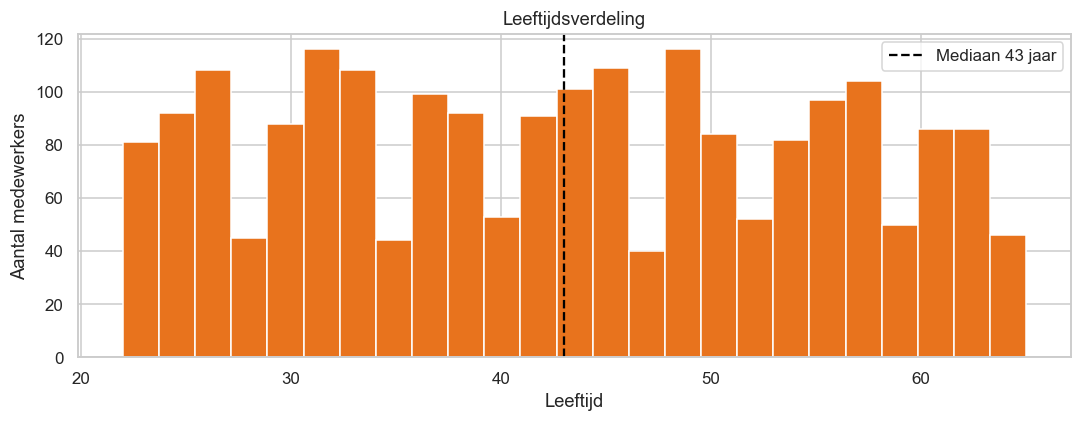

count    2070.0
mean       42.8
std        12.2
min        22.0
25%        32.0
50%        43.0
75%        53.0
max        65.0
Name: leeftijd, dtype: float64

In [10]:
med['leeftijd'] = ((pd.Timestamp('2026-01-01') - med['geboortedatum']).dt.days / 365.25).round(0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(med['leeftijd'].dropna(), bins=25, color='#E8731D', edgecolor='white')
ax.axvline(med['leeftijd'].median(), color='black', linestyle='--',
           label=f"Mediaan {med['leeftijd'].median():.0f} jaar")
ax.set_xlabel('Leeftijd')
ax.set_ylabel('Aantal medewerkers')
ax.set_title('Leeftijdsverdeling')
ax.legend()
plt.tight_layout()
plt.show()

med['leeftijd'].describe().round(1)

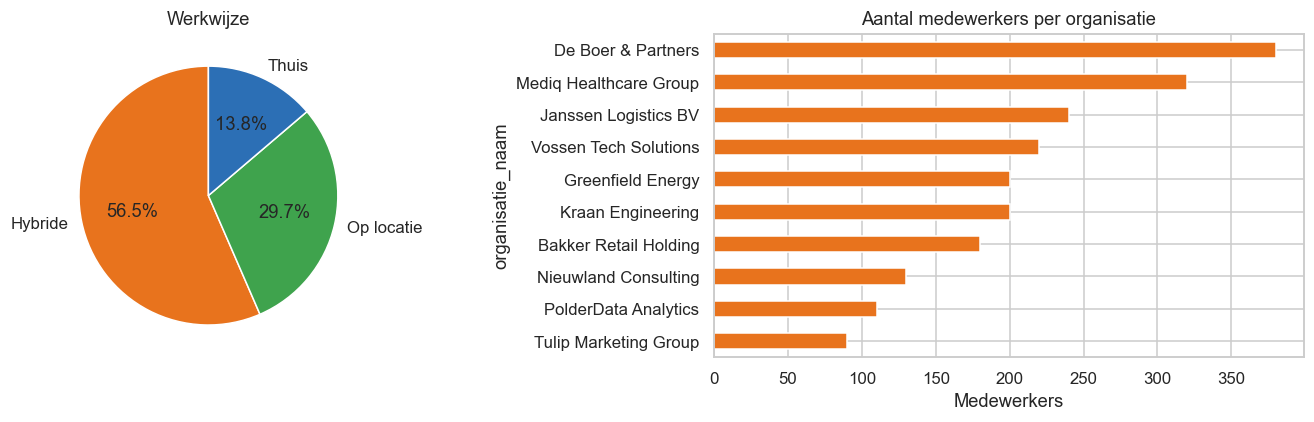

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

wm = med['werkwijze'].value_counts()
axes[0].pie(wm, labels=wm.index, autopct='%1.1f%%', startangle=90,
            colors=['#E8731D', '#3FA34D', '#2C6FB5'])
axes[0].set_title('Werkwijze')

# Per organisatie hoeveel medewerkers
med_org = med.merge(org[['organisatie_id','organisatie_naam']], on='organisatie_id')
(med_org.groupby('organisatie_naam').size()
        .sort_values().plot.barh(ax=axes[1], color='#E8731D'))
axes[1].set_xlabel('Medewerkers')
axes[1].set_title('Aantal medewerkers per organisatie')
plt.tight_layout()
plt.show()

55% hybride, 30% op locatie, 15% thuis. Realistisch voor NL bedrijven. Bakker en De Boer zijn de grootste klanten.

## 4. Wanneer sporten mensen?

Uit mijn onderzoek had ik de hypothese dat de meeste sportactiviteiten in de lunchpauze (12u) en direct na werk (17–18u) plaatsvinden. Klopt dat?

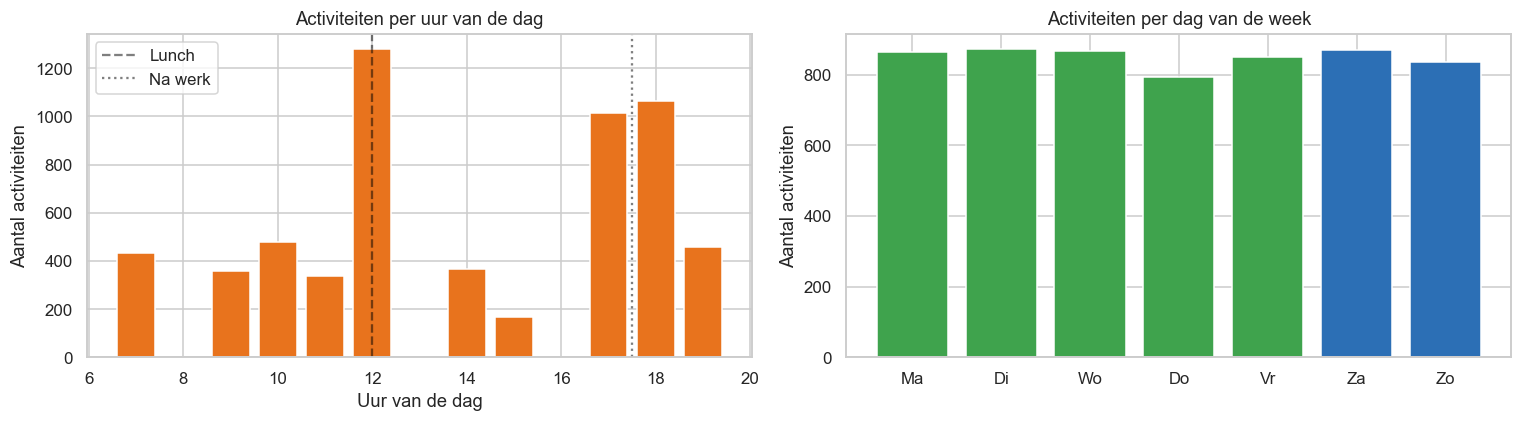

In [11]:
act['uur'] = act['geplande_tijd'].dt.hour
act['weekdag'] = act['geplande_tijd'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

uurlijks = act['uur'].value_counts().sort_index()
axes[0].bar(uurlijks.index, uurlijks.values, color='#E8731D')
axes[0].axvline(12, color='black', linestyle='--', alpha=0.5, label='Lunch')
axes[0].axvline(17.5, color='black', linestyle=':', alpha=0.5, label='Na werk')
axes[0].set_xlabel('Uur van de dag')
axes[0].set_ylabel('Aantal activiteiten')
axes[0].set_title('Activiteiten per uur van de dag')
axes[0].legend()

volgorde = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dagelijks = act['weekdag'].value_counts().reindex(volgorde).fillna(0)
kleuren = ['#3FA34D']*5 + ['#2C6FB5']*2
axes[1].bar(['Ma','Di','Wo','Do','Vr','Za','Zo'], dagelijks.values, color=kleuren)
axes[1].set_title('Activiteiten per dag van de week')
axes[1].set_ylabel('Aantal activiteiten')
plt.tight_layout()
plt.show()

Duidelijke piek rond 12u en een tweede piek rond 17–18u. Weekenden zijn duidelijk rustiger, logisch voor een werkplatform.


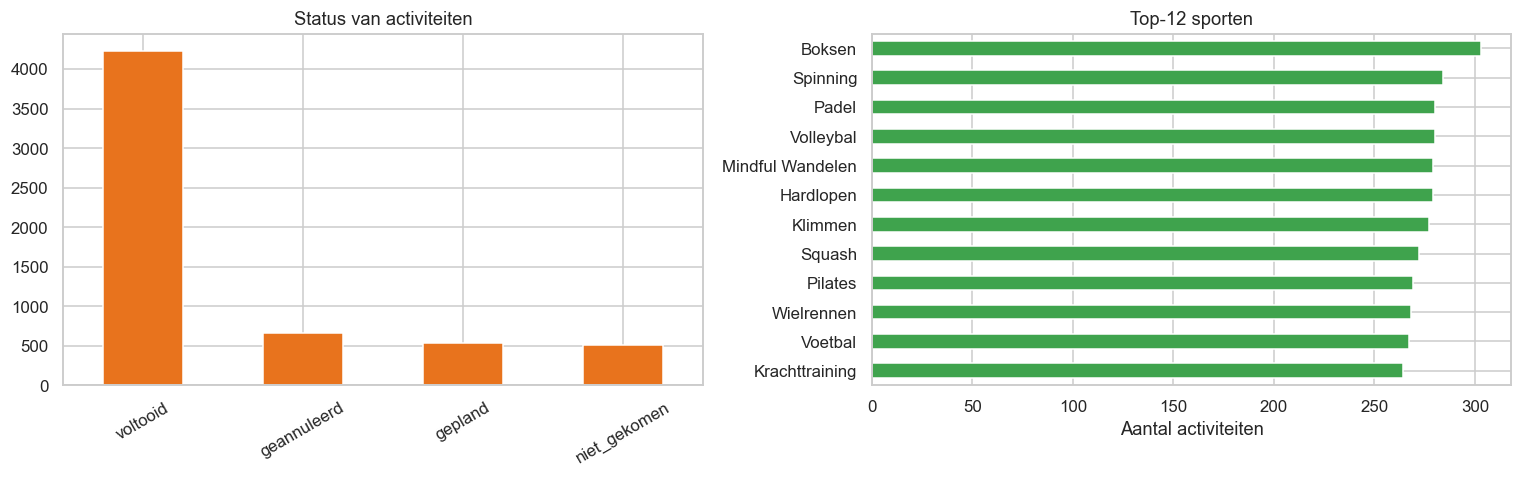

In [12]:
#Welke sporten zijn populair?
act_sp = act.merge(sp[['sport_id','sport_naam']], on='sport_id', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

act['status'].value_counts().plot.bar(ax=axes[0], color='#E8731D')
axes[0].set_title('Status van activiteiten')
axes[0].tick_params(axis='x', rotation=30)

(act_sp['sport_naam'].value_counts().head(12).sort_values()
        .plot.barh(ax=axes[1], color='#3FA34D'))
axes[1].set_title('Top-12 sporten')
axes[1].set_xlabel('Aantal activiteiten')
plt.tight_layout()
plt.show()

## 5. De funnel: aanmelden → komen → feedback

Het platform verlaagt volgens mijn advies de drempel tot deelname. Maar hoeveel % van de aanmeldingen leidt echt tot een aanwezige deelnemer? En hoeveel daarvan vult feedback in?

,stap,aantal,vs vorige,vs aanmeld
0,Aangemeld,55461,-,100.0%
1,Bevestigd,45098,81.3%,81.3%
2,Bijgewoond,34308,76.1%,61.9%
3,Feedback gegeven,18801,54.8%,33.9%


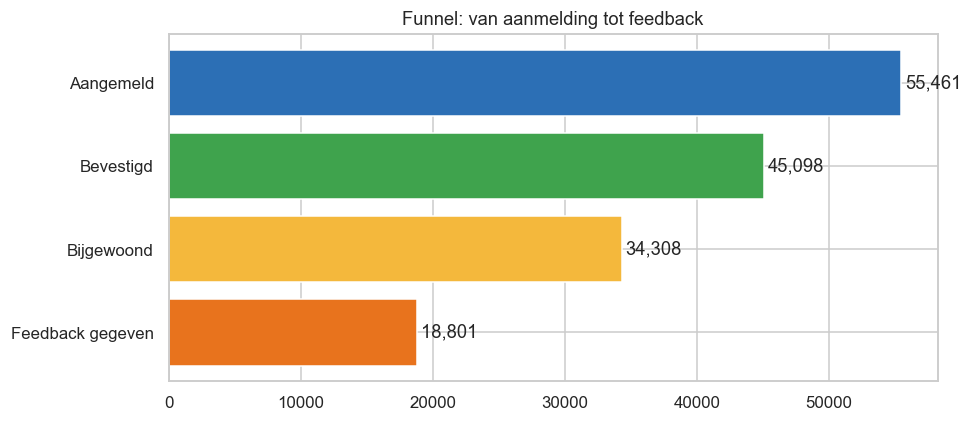

In [13]:
# Alleen kijken naar activiteiten die ECHT al hebben plaatsgevonden.
dn_klaar = dn[dn['bijgewoond'].notna()].copy()  # gepland heeft NaN

n_aanmelding = len(dn_klaar)
n_bevestigd  = (dn_klaar['status'] == 'bevestigd').sum()
n_bijgewoond = (dn_klaar['bijgewoond'].astype(float) == 1).sum()
n_feedback   = len(fb)

funnel = pd.DataFrame({
    'stap': ['Aangemeld', 'Bevestigd', 'Bijgewoond', 'Feedback gegeven'],
    'aantal': [n_aanmelding, n_bevestigd, n_bijgewoond, n_feedback],
})
funnel['vs vorige']  = ['-'] + [f'{funnel["aantal"][i] / funnel["aantal"][i-1] * 100:.1f}%'
                                 for i in range(1, len(funnel))]
funnel['vs aanmeld'] = [f'{v / n_aanmelding * 100:.1f}%' for v in funnel['aantal']]
display(funnel)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(funnel['stap'][::-1], funnel['aantal'][::-1],
        color=['#E8731D', '#F4B83C', '#3FA34D', '#2C6FB5'])
for i, v in enumerate(funnel['aantal'][::-1]):
    ax.text(v + 300, i, f'{v:,}', va='center')
ax.set_title('Funnel: van aanmelding tot feedback')
plt.tight_layout()
plt.show()

~80% van de bevestigde aanmeldingen komt opdagen, en daarvan vult ~55% feedback in. Voor een vitaliteits-platform is dat een prima conversie. 

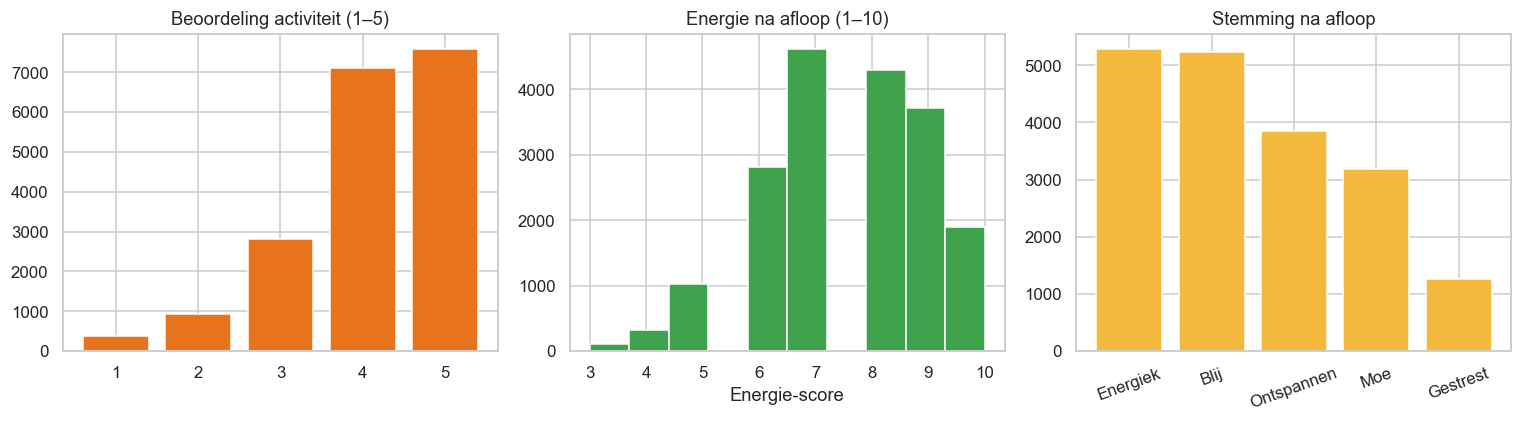

In [14]:
# Hoe positief mensen zijn na een activiteit.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

beo = fb['beoordeling'].value_counts().sort_index()
axes[0].bar(beo.index.astype(str), beo.values, color='#E8731D')
axes[0].set_title('Beoordeling activiteit (1–5)')

axes[1].hist(fb['energie_na_1tot10'].dropna(), bins=10, color='#3FA34D')
axes[1].set_title('Energie na afloop (1–10)')
axes[1].set_xlabel('Energie-score')

mood = fb['stemming_na'].value_counts().sort_values(ascending=False)
axes[2].bar(mood.index, mood.values, color='#F4B83C')
axes[2].set_title('Stemming na afloop')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 6. Beweging, stress en energie

In mijn onderzoek heb ik onderzocht dat regelmatige beweging stress verlaagt en energie verhoogt. Dit wil ik toetsen met mijn data.

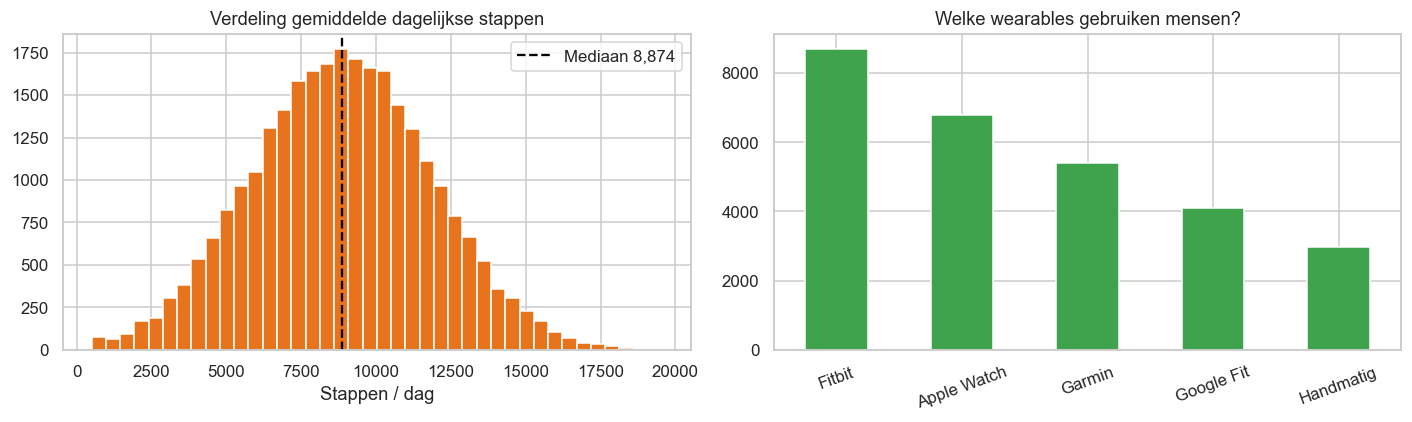

In [15]:
stappen = gez['gem_stappen_per_dag'].dropna()
stappen_valid = stappen[stappen > 0]   # 0-stappen DQ-issue eruit

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(stappen_valid, bins=40, color='#E8731D', edgecolor='white')
axes[0].axvline(stappen_valid.median(), color='black', linestyle='--',
                label=f'Mediaan {stappen_valid.median():,.0f}')
axes[0].set_title('Verdeling gemiddelde dagelijkse stappen')
axes[0].set_xlabel('Stappen / dag')
axes[0].legend()

gez['data_bron'].value_counts().plot.bar(ax=axes[1], color='#3FA34D')
axes[1].set_title('Welke wearables gebruiken mensen?')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

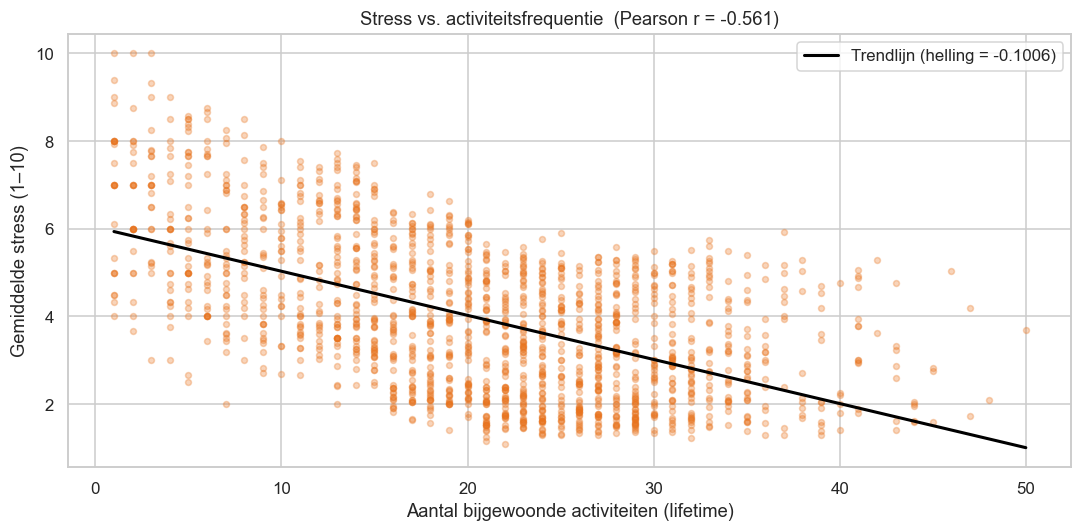

In [16]:
# Per medewerker: gemiddelde stress vs aantal bijgewoonde activiteiten.
# Hypothese: actiever = lagere stress.

act_per_med = (dn[dn['bijgewoond'].astype(float) == 1]
               .groupby('medewerker_id').size()
               .reset_index(name='bijgewoond_aantal'))

stress_per_med = (gez.groupby('medewerker_id')['stress_1tot10']
                     .mean().reset_index(name='gem_stress'))

# medewerker_id is numeriek in gez maar string in act_per_med (vanuit dn)
stress_per_med['medewerker_id'] = stress_per_med['medewerker_id'].astype(str)
act_per_med['medewerker_id'] = act_per_med['medewerker_id'].astype(str)

combo = act_per_med.merge(stress_per_med, on='medewerker_id', how='inner').dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(combo['bijgewoond_aantal'], combo['gem_stress'],
           alpha=0.3, s=15, color='#E8731D')

# Trendlijn erbij om de richting beter te zien
m, b = np.polyfit(combo['bijgewoond_aantal'], combo['gem_stress'], 1)
xr = np.linspace(combo['bijgewoond_aantal'].min(), combo['bijgewoond_aantal'].max(), 100)
ax.plot(xr, m*xr + b, color='black', linewidth=2, label=f'Trendlijn (helling = {m:.4f})')

r = combo[['bijgewoond_aantal','gem_stress']].corr().iloc[0, 1]
ax.set_xlabel('Aantal bijgewoonde activiteiten (lifetime)')
ax.set_ylabel('Gemiddelde stress (1–10)')
ax.set_title(f'Stress vs. activiteitsfrequentie  (Pearson r = {r:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

Een negatief verband tussen aantal bijgewoonde activiteiten en gemiddelde stress: hoe meer iemand sport, hoe lager de gerapporteerde stress.


## 7. Hoe sterk is dat verband? 

Als iemand 10 extra activiteiten bijwoont, hoeveel lager is zijn gemiddelde stress dan?

In [17]:
# Voor een regressie heb ik 1 rij per medewerker nodig, met alle variabelen
# als getal. Dus eerst aggregeren.

# Aantal bijgewoonde activiteiten per medewerker
acts_per_med = (dn[dn['bijgewoond'].astype(float) == 1]
                .groupby('medewerker_id').size().rename('n_act'))

# Gemiddelde stress + slaap uit gezondheidsmetingen
gez_per_med = (gez.groupby('medewerker_id')
                  .agg(gem_stress=('stress_1tot10', 'mean'),
                       gem_slaap_uren=('gem_slaap_uren', 'mean')))

# Leeftijd was al berekend in §3, koppelen via medewerker_id
df_reg = (med[['medewerker_id', 'leeftijd', 'werkwijze']]
          .merge(acts_per_med, left_on='medewerker_id', right_index=True)
          .merge(gez_per_med,  left_on='medewerker_id', right_index=True)
          .dropna(subset=['n_act', 'gem_stress', 'gem_slaap_uren', 'leeftijd']))

print(f'Regressie-set: {len(df_reg)} medewerkers (na drop NaN)')
df_reg.head()

Regressie-set: 1603 medewerkers (na drop NaN)


,medewerker_id,leeftijd,werkwijze,n_act,gem_stress,gem_slaap_uren
2,3,53.0,Hybride,16,3.600000,6.860000
3,4,37.0,Op locatie,7,5.500000,7.866667
5,6,35.0,Hybride,9,7.875000,6.437500
7,8,50.0,Thuis,3,7.777778,7.455556
8,9,53.0,Op locatie,13,3.090909,7.708333


Vergelijking:  stress = 6.039 + (-0.1006) × aantal_activiteiten
R²:            0.3143
Pearson r:     -0.561
p-waarde:      2.52e-133


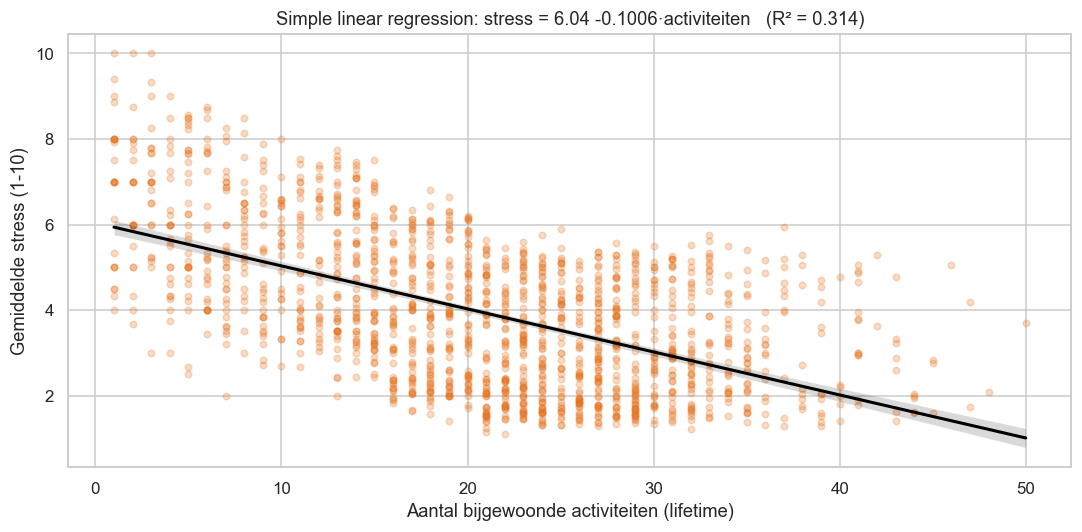

In [18]:
from sklearn.linear_model import LinearRegression
from scipy import stats

# Simpele regressie: stress ~ aantal activiteiten
X = df_reg[['n_act']]
y = df_reg['gem_stress']
model = LinearRegression().fit(X, y)

slope     = model.coef_[0]
intercept = model.intercept_
r2_simple = model.score(X, y)

# scipy.stats voor de p-waarde van Pearson r
pearson_r, p_value = stats.pearsonr(df_reg['n_act'], df_reg['gem_stress'])

print(f'Vergelijking:  stress = {intercept:.3f} + ({slope:+.4f}) × aantal_activiteiten')
print(f'R²:            {r2_simple:.4f}')
print(f'Pearson r:     {pearson_r:+.3f}')
print(f'p-waarde:      {p_value:.2e}')

# Visueel
fig, ax = plt.subplots(figsize=(10, 5))
sns.regplot(
    data=df_reg, x='n_act', y='gem_stress',
    scatter_kws={'alpha': 0.25, 's': 18, 'color': '#E8731D'},
    line_kws={'color': 'black', 'linewidth': 2},
    ax=ax,
)
ax.set_xlabel('Aantal bijgewoonde activiteiten (lifetime)')
ax.set_ylabel('Gemiddelde stress (1-10)')
ax.set_title(f'Simple linear regression: stress = {intercept:.2f} {slope:+.4f}·activiteiten   (R² = {r2_simple:.3f})')
plt.tight_layout()
plt.show()

Wat zegt deze regressie?

- **Helling**: rond -0.10. Voor elke extra activiteit daalt de gemiddelde stress met ~0.1 punt op de 1–10 schaal. **10 extra activiteiten ≈ 1 punt lager op stress**, een merkbaar verschil.
- **p-waarde**: praktisch 0, ruim onder de 0.001-drempel. Statistisch zeer significant.
- **R²**: ~0.31. Aantal activiteiten verklaart ~31% van de variatie in stress. Voor sociale-wetenschap-data een sterke effectgrootte.

Conclusie: deze regressie ondersteunt het centrale argument van mijn bedrijfsadvies. Meer beweging via ActiConnect helpt om stress te verlagen.

## 8. Maakt thuiswerken nu echt verschil?

Centraal punt uit mijn advies: hybride/thuiswerkers zouden sociaal geïsoleerd raken. Als dat klopt, zou je verwachten dat thuiswerkers minder vaak komen opdagen bij ActiConnect-activiteiten (want minder verbonden met collega's).

,aanmeldingen,bijgewoond,opkomst_pct
werkwijze,,,
Hybride,33014,19285,58.4
Op locatie,17378,10249,59.0
Thuis,8238,4774,58.0


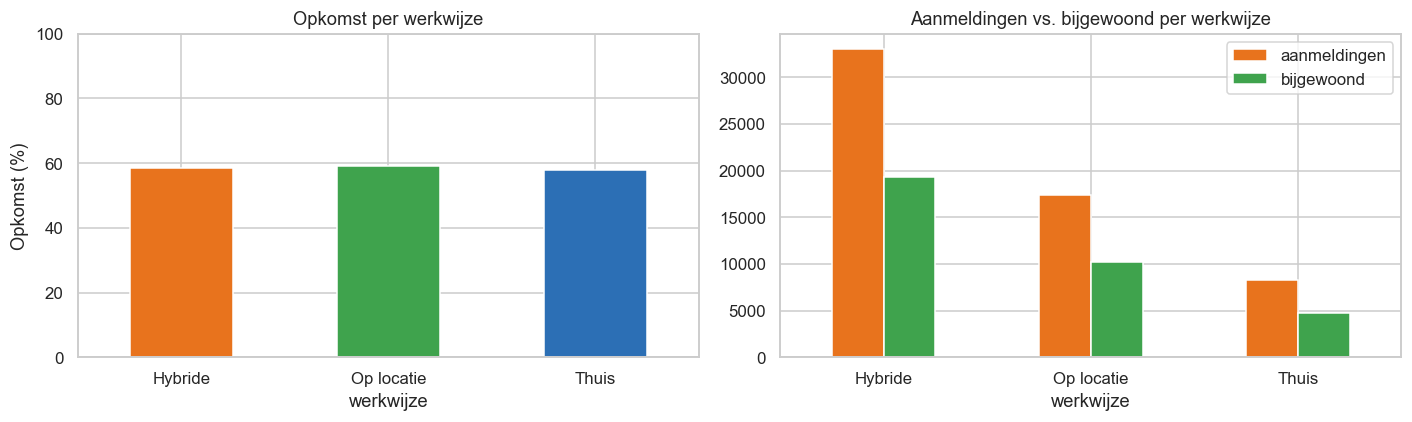

In [19]:
med_dn = dn.merge(med[['medewerker_id','werkwijze']], on='medewerker_id', how='left')

wm_stat = (
    med_dn.groupby('werkwijze')
          .agg(aanmeldingen=('deelname_id','count'),
               bijgewoond=('bijgewoond', lambda x: (x.astype(float) == 1).sum()))
          .assign(opkomst_pct=lambda d: (d['bijgewoond'] / d['aanmeldingen'] * 100).round(1))
)
display(wm_stat)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
kleuren = {'Hybride': '#E8731D', 'Op locatie': '#3FA34D', 'Thuis': '#2C6FB5'}
wm_stat['opkomst_pct'].plot.bar(
    ax=axes[0],
    color=[kleuren.get(x, '#888') for x in wm_stat.index],
)
axes[0].set_ylim(0, 100)
axes[0].set_ylabel('Opkomst (%)')
axes[0].set_title('Opkomst per werkwijze')
axes[0].tick_params(axis='x', rotation=0)

wm_stat[['aanmeldingen','bijgewoond']].plot.bar(ax=axes[1], color=['#E8731D','#3FA34D'])
axes[1].set_title('Aanmeldingen vs. bijgewoond per werkwijze')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

De opkomst-percentages tussen de drie groepen liggen vrij dicht bij elkaar. (Mischien mijn mock-data beter moeten genereren)